Total arrows plotted: 40000
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)


Total arrows plotted: 40000
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)


/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


Total arrows plotted: 40000
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)
Generated squid glyph mesh with 66204 points and 98080 polygons scalar values shape: (66204,)


/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


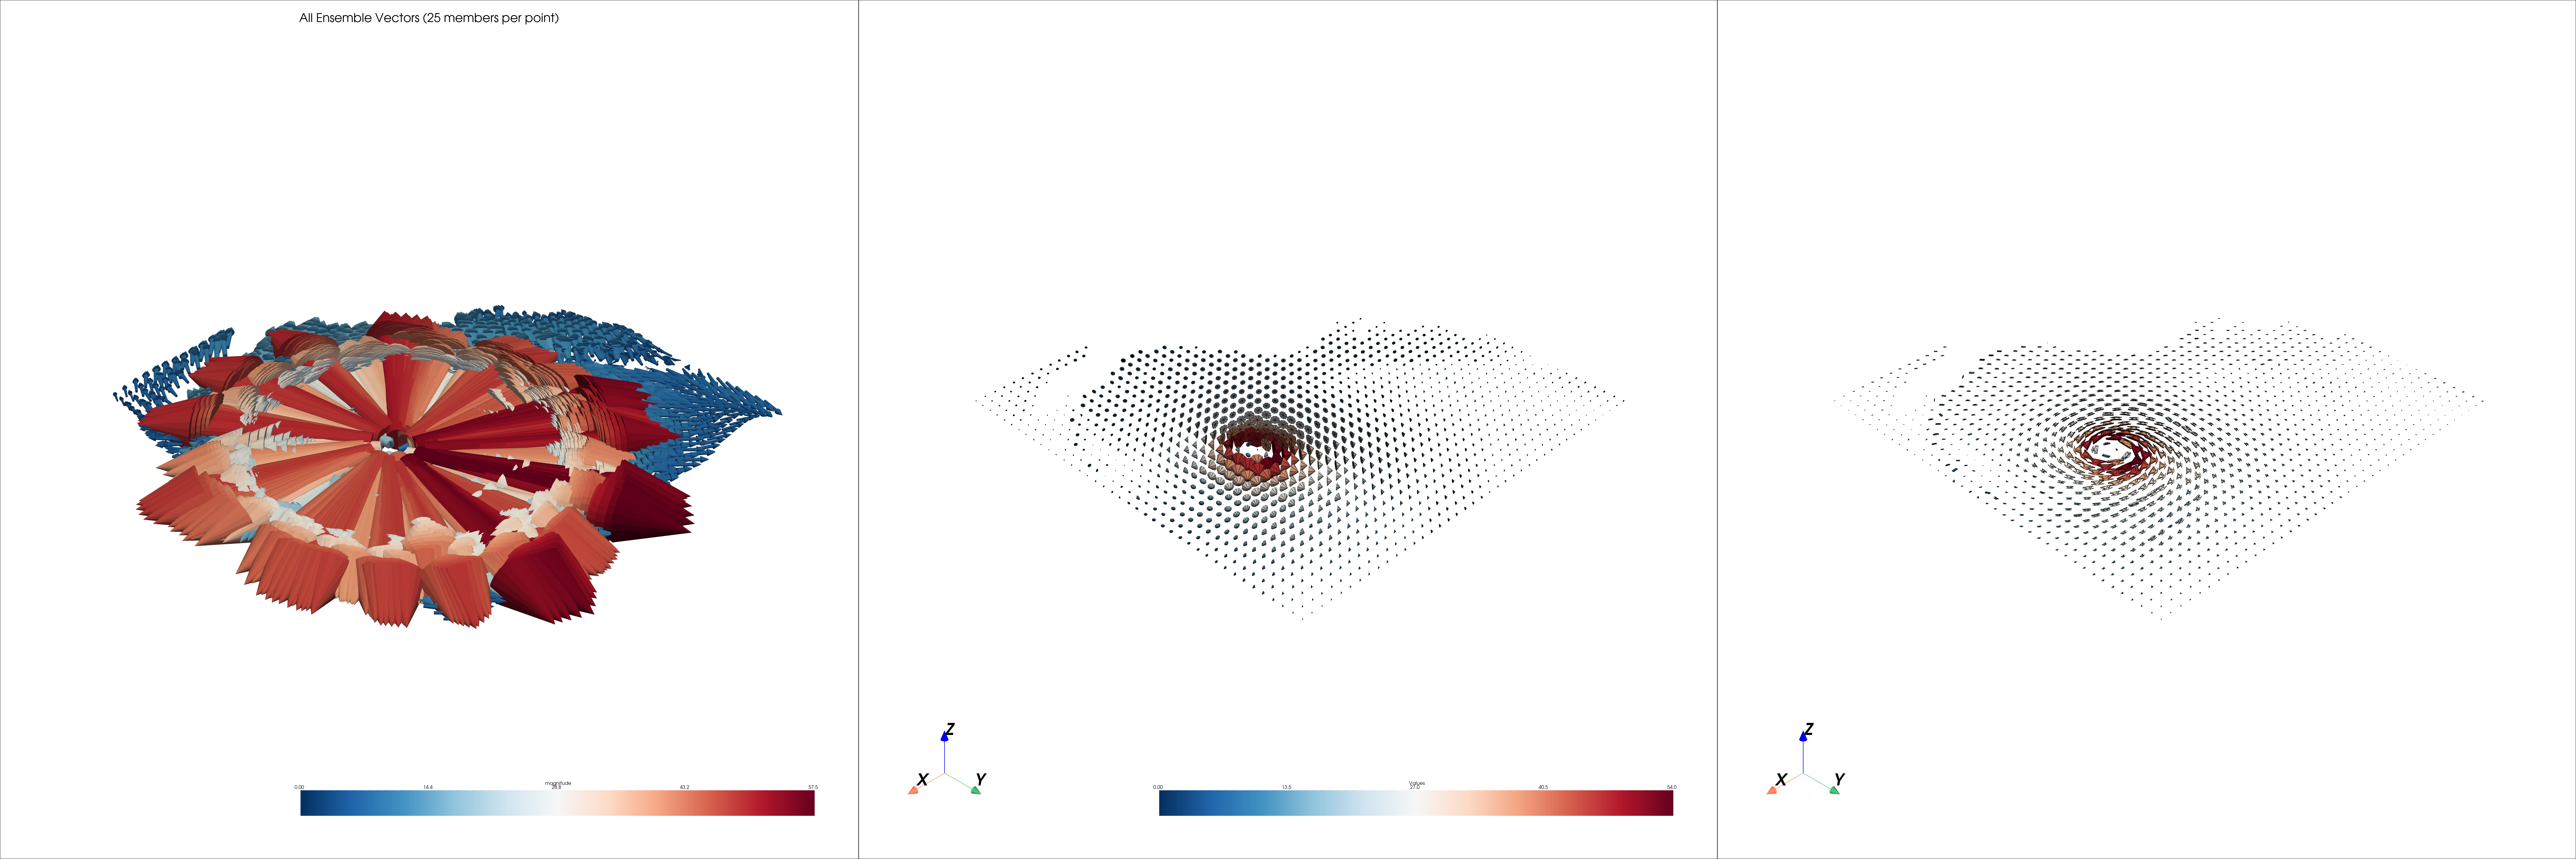

In [ ]:
from vtk.numpy_interface import dataset_adapter as dsa
from uvisbox.Modules.SquidGlyphs import squid_glyph_3D 
from uvisbox.Modules.ConeGlyphs import cone_glyph
import numpy as np
import pyvista as pv

def load_isabel_data():
    data = np.load("../uvisbox/Datasets/hurricane_isabel_ensemble_vectors_time10.npz")
    positions = data['positions']
    vectors = data['vectors']
    magnitudes = np.linalg.norm(vectors, axis=2)
    median_magnitudes = np.median(magnitudes, axis=1)
    return positions, vectors, median_magnitudes

# Load data
positions, ensemble_vectors, median_magnitudes = load_isabel_data()

# Visualization parameters
scaling_factor = 0.2
percenti_value = 95

plotter = pv.Plotter(shape=(1, 3), window_size=[9600, 3200])
plotter.subplot(0, 0)

# Plot ensemble vectors - all members using PyVista arrows
num_points = positions.shape[0]
num_ensembles = ensemble_vectors.shape[1]

# Replicate positions for each ensemble member
all_positions = np.repeat(positions, num_ensembles, axis=0)

# Flatten ensemble vectors to match positions
all_vectors = ensemble_vectors.reshape(-1, 3)

# Calculate magnitudes for all vectors
all_magnitudes = np.linalg.norm(all_vectors, axis=1)

# plotter = pv.Plotter(window_size=[3200, 3200])
point_cloud = pv.PolyData(all_positions)
point_cloud['vectors'] = all_vectors
point_cloud['magnitude'] = all_magnitudes

# Increase arrow size — adjust multiplier as needed
# Create a larger arrow geometry
arrow_geom = pv.Arrow(tip_length=0.25, tip_radius=0.1, shaft_radius=0.05)
arrow_size_multiplier = 5.0  # Increase this value for larger arrows

arrows = point_cloud.glyph(orient='vectors', scale='magnitude',
                           factor=arrow_size_multiplier, geom=pv.Arrow())
plotter.add_mesh(arrows, scalars='magnitude', cmap='RdBu_r',
                show_scalar_bar=True, opacity=1.0)
plotter.add_title(f'All Ensemble Vectors ({num_ensembles} members per point)')
# plotter.show()

print(f"Total arrows plotted: {num_points * num_ensembles}")

plotter.subplot(0, 1)
plotter, points, triangles = cone_glyph(positions, ensemble_vectors, point_values=median_magnitudes, 
                                        percentile=percenti_value, scale=scaling_factor, ax=plotter)

plotter.subplot(0, 2)
plotter, points, triangles = squid_glyph_3D(positions, ensemble_vectors, point_values=median_magnitudes, 
                                            percentile=percenti_value, scale=scaling_factor, ax=plotter)
plotter.link_views()
plotter.show()
plotter.screenshot("hurricane_isabel_cone_squid_glyphs2.png")




/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


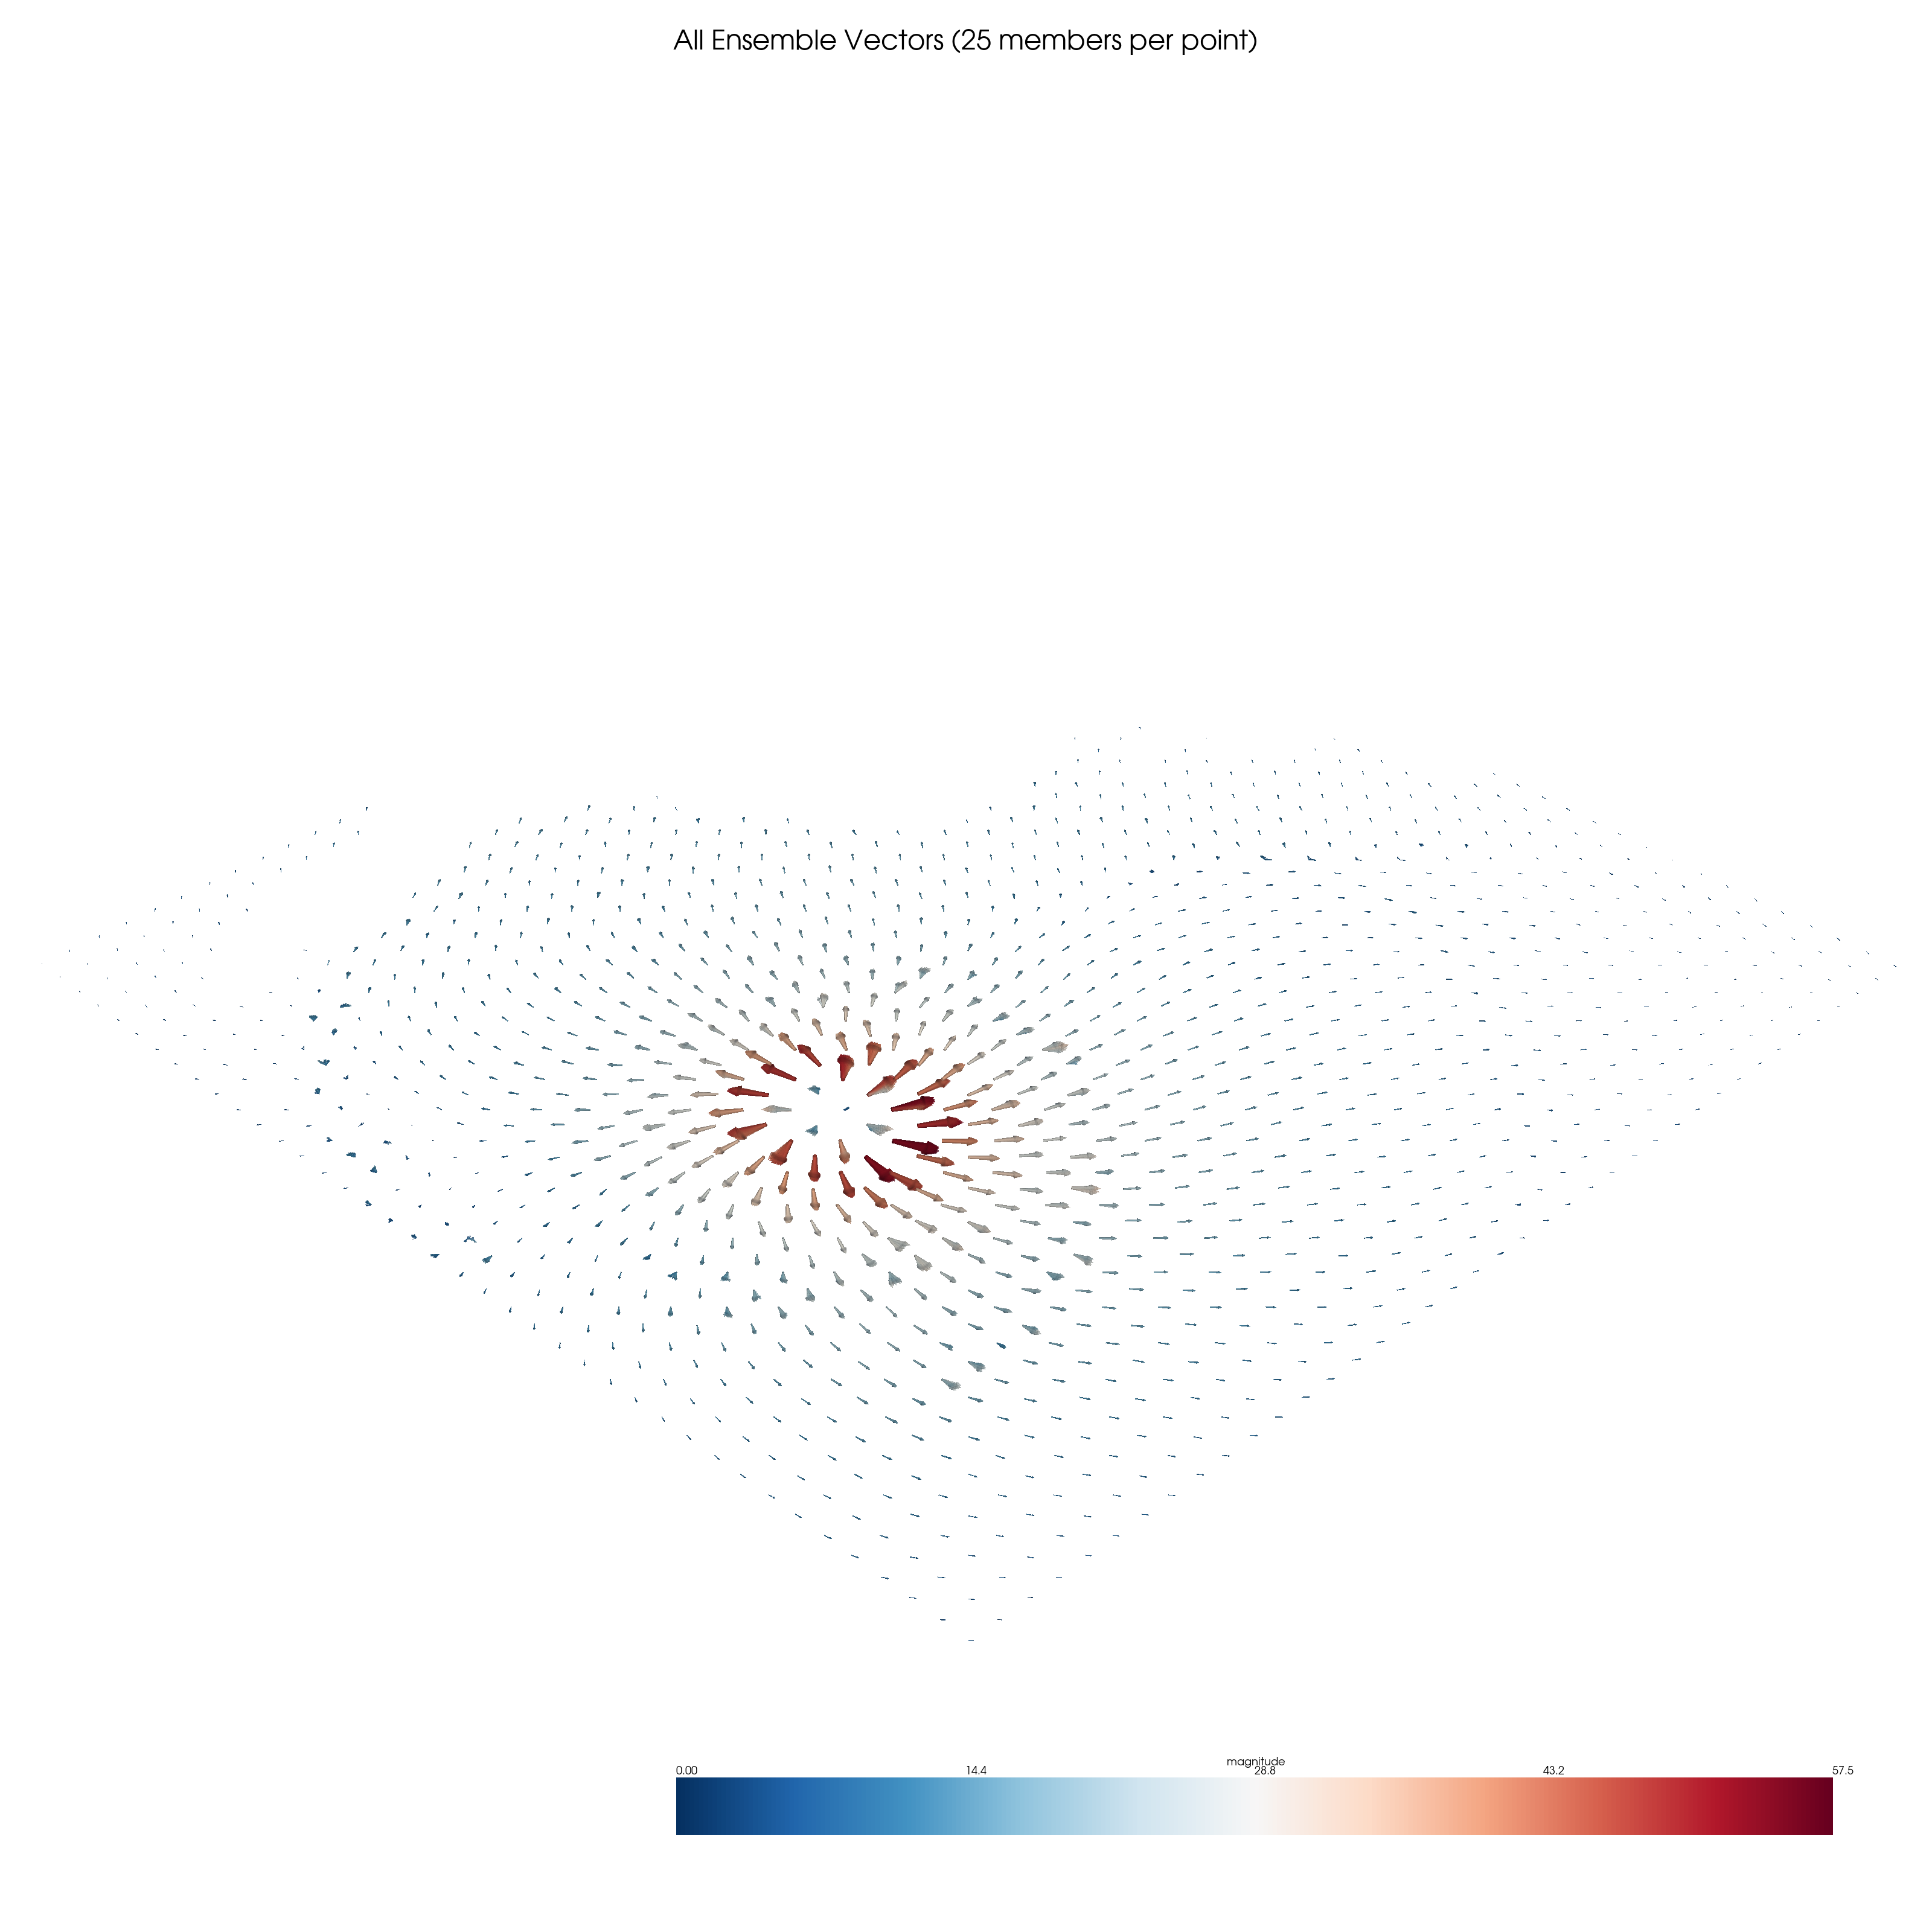

Total arrows plotted: 40000


In [15]:
# Plot ensemble vectors using PyVista arrows
mean_vectors = np.mean(ensemble_vectors, axis=1)

plotter = pv.Plotter(window_size=[3200, 3200])
point_cloud = pv.PolyData(positions)
point_cloud['vectors'] = mean_vectors
point_cloud['magnitude'] = median_magnitudes

arrows = point_cloud.glyph(orient='vectors', scale='magnitude', 
                            factor=0.3, geom=pv.Arrow())
plotter.add_mesh(arrows, scalars='magnitude', cmap='plasma',
                show_scalar_bar=True)
plotter.add_title('Mean Vector Field')
plotter.show()
'RdBu_r'